In [ ]:
!pip install opendatasets

In [ ]:
# provjera
!nvidia-smi


Fri Jan 16 22:15:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/msambare/fer2013/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nikolajami
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013


100%|██████████| 60.3M/60.3M [00:00<00:00, 810MB/s]

In [ ]:
import torch
import numpy as np

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from os.path import join, realpath
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Grayscale(num_output_channels=1),
    v2.Normalize(mean=[0.35], std=[0.48])
])

projekt_root = realpath(".")

train_dataset = ImageFolder(root=join(projekt_root, "fer2013/train"), transform=transform)
test_dataset = ImageFolder(root=join(projekt_root, "fer2013/test"), transform=transform)

train_labels = [label for _, label in train_dataset.samples]

# Kreiranje indeksa za podjelu
train_indices, val_indices = train_test_split(
    range(len(train_dataset)),      # Lista indeksa od 0 do N-1
    test_size=0.2,                  # 20% za validaciju
    stratify=train_labels,          # osigurava da ce udio svake klase u train_indices i val_indices bude približno isti kao u originalnom train_dataset
    random_state=40
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

train_data = DataLoader(train_subset, batch_size=32, shuffle=True)
val_data = DataLoader(val_subset, batch_size=32, shuffle=False)
test_data = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Veličina novog skupa za učenje: {len(train_subset)}")
print(f"Veličina skupa za validaciju: {len(val_subset)}")
print(f"Veličina skupa za testiranje: {len(test_dataset)}")


Veličina novog skupa za učenje: 22967
Veličina skupa za validaciju: 5742
Veličina skupa za testiranje: 7178


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights, resnet50, ResNet50_Weights
import time
import copy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


#GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uređaj: {device}\n")


def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    """Funkcija za treniranje i validaciju modela."""
    start_time = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        print('-' * 10)
        print(f'Epoha {epoch+1}/{num_epochs}')

        #Trening
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)

        #Validacija
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with torch.no_grad():
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = running_corrects.double() / len(val_loader.dataset)

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc.cpu())
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc.cpu())

        print(f'Trening -> Gubitak: {epoch_train_loss:.4f} Točnost: {epoch_train_acc:.4f}')
        print(f'Validacija -> Gubitak: {epoch_val_loss:.4f} Točnost: {epoch_val_acc:.4f}')

        #spremi najbolji model
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    print(f'\nNajbolja validacijska točnost: {best_acc:.4f}')

    #ucitaj najbolje težine u model
    model.load_state_dict(best_model_wts)

    return model, history


def evaluate_on_test_set(model, test_loader):
  """Konačna evaluacija na testnom setu."""
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = model(inputs)
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  accuracy = 100 * correct / total

  print(f"\nKONAČNA TOČNOST na testnom setu: {accuracy:.4f} %")


def plot_learning_curves(history, title="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Gubitak
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Trening gubitak")
    plt.plot(epochs, history["val_loss"], label="Validacijski gubitak")
    plt.xlabel("Epoha")
    plt.ylabel("Gubitak")
    plt.legend()
    plt.title(f"{title} - GUBITAK")

    # Točnost
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Trening točnost")
    plt.plot(epochs, history["val_acc"], label="Validacijska točnost")
    plt.xlabel("Epoha")
    plt.ylabel("Točnost")
    plt.legend()
    plt.title(f"{title} - TOČNOST")

    plt.show()


def evaluate_model_with_cm(model, test_loader, class_names, model_name="Model"):
    print(f"\n=== Evaluacija: {model_name} ===")

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title(f"Matrica zabune: {model_name}")
    plt.show()

Koristi se uređaj: cuda



In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from torchvision.transforms import v2
from os.path import join, realpath
from sklearn.model_selection import train_test_split

transform_train = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Grayscale(num_output_channels=3),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(10),
    v2.RandomResizedCrop(224, scale=(0.9, 1.0)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet norma
])

transform_eval = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Grayscale(num_output_channels=3),
    v2.Resize((224, 224)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


projekt_root = realpath(".")

# train i val isti skup, ali druge transformacije
train_dataset_full = ImageFolder(root=join(projekt_root, "fer2013/train"), transform=transform_train)
val_dataset_full   = ImageFolder(root=join(projekt_root, "fer2013/train"), transform=transform_eval)
test_dataset       = ImageFolder(root=join(projekt_root, "fer2013/test"),  transform=transform_eval)

class_names = train_dataset_full.classes
num_classes = len(class_names)

train_labels = [label for _, label in train_dataset_full.samples]

train_indices, val_indices = train_test_split(
    range(len(train_dataset_full)),
    test_size=0.2,               # 20% za validaciju
    stratify=train_labels,       # osigurava da ce udio svake klase u train_indices i val_indices bude približno isti kao u originalnom train_dataset
    random_state=40
)

train_subset = Subset(train_dataset_full, train_indices)
val_subset   = Subset(val_dataset_full,   val_indices)

batch_size = 64
train_data = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_data   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False)
test_data  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Klase ({num_classes}): {class_names}")
print(f"Veličina skupa za učenje: {len(train_subset)}")
print(f"Veličina skupa za validaciju: {len(val_subset)}")
print(f"Veličina skupa za testiranje: {len(test_dataset)}")


Klase (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Veličina skupa za učenje: 22967
Veličina skupa za validaciju: 5742
Veličina skupa za testiranje: 7178


Ispis statistike o podacima i prikaz par slika za verifikaciju.

Klase: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Broj klasa: 7
Velicina skupa za ucenje: 28709
Velicina skupa za testiranje: 7178



['sad', 'angry', 'happy', 'sad']


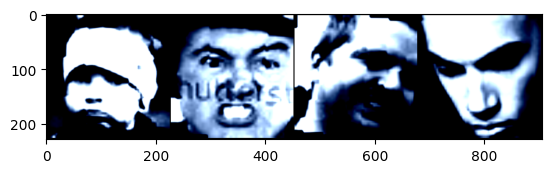

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

train_dataset = train_dataset_full
print(f"Klase: {train_dataset.classes}")
print(f"Broj klasa: {len(train_dataset.classes)}")
print(f"Velicina skupa za ucenje: {len(train_dataset)}")
print(f"Velicina skupa za testiranje: {len(test_dataset)}")

# prikaz slika
dataiter = iter(train_data)
images, labels = next(dataiter)
print()
print([train_dataset.classes[l] for l in labels[:4]])
img_grid = make_grid(images[:4])
plt.imshow(img_grid.permute(1, 2, 0))
plt.show()

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights, resnet50, ResNet50_Weights
import time
import copy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


#GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uređaj: {device}\n")


def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    """Funkcija za treniranje i validaciju modela."""
    start_time = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        print('-' * 10)
        print(f'Epoha {epoch+1}/{num_epochs}')

        #Trening
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)

        #Validacija
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with torch.no_grad():
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = running_corrects.double() / len(val_loader.dataset)

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc.cpu())
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc.cpu())

        print(f'Trening -> Gubitak: {epoch_train_loss:.4f} Točnost: {epoch_train_acc:.4f}')
        print(f'Validacija -> Gubitak: {epoch_val_loss:.4f} Točnost: {epoch_val_acc:.4f}')

        #spremi najbolji model
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    print(f'\nNajbolja validacijska točnost: {best_acc:.4f}')

    #ucitaj najbolje težine u model
    model.load_state_dict(best_model_wts)

    return model, history


def evaluate_on_test_set(model, test_loader):
  """Konačna evaluacija na testnom setu."""
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = model(inputs)
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  accuracy = 100 * correct / total

  print(f"\nKONAČNA TOČNOST na testnom setu: {accuracy:.4f} %")


def plot_learning_curves(history, title="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Gubitak
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Trening gubitak")
    plt.plot(epochs, history["val_loss"], label="Validacijski gubitak")
    plt.xlabel("Epoha")
    plt.ylabel("Gubitak")
    plt.legend()
    plt.title(f"{title} - GUBITAK")

    # Točnost
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Trening točnost")
    plt.plot(epochs, history["val_acc"], label="Validacijska točnost")
    plt.xlabel("Epoha")
    plt.ylabel("Točnost")
    plt.legend()
    plt.title(f"{title} - TOČNOST")

    plt.show()


def evaluate_model_with_cm(model, test_loader, class_names, model_name="Model"):
    print(f"\n=== Evaluacija: {model_name} ===")

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title(f"Matrica zabune: {model_name}")
    plt.show()

Koristi se uređaj: cuda



# **RESNET18**



--- Početak s ResNet18 (224x224, 3ch) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


----------
Epoha 1/10
Trening -> Gubitak: 1.3658 Točnost: 0.4859
Validacija -> Gubitak: 1.0515 Točnost: 0.6061
----------
Epoha 2/10
Trening -> Gubitak: 1.0767 Točnost: 0.5956
Validacija -> Gubitak: 0.9689 Točnost: 0.6271
----------
Epoha 3/10
Trening -> Gubitak: 0.9713 Točnost: 0.6372
Validacija -> Gubitak: 0.9553 Točnost: 0.6459
----------
Epoha 4/10
Trening -> Gubitak: 0.8994 Točnost: 0.6674
Validacija -> Gubitak: 0.9381 Točnost: 0.6529
----------
Epoha 5/10
Trening -> Gubitak: 0.8393 Točnost: 0.6882
Validacija -> Gubitak: 0.9086 Točnost: 0.6696
----------
Epoha 6/10
Trening -> Gubitak: 0.7828 Točnost: 0.7092
Validacija -> Gubitak: 0.9214 Točnost: 0.6627
----------
Epoha 7/10
Trening -> Gubitak: 0.7227 Točnost: 0.7341
Validacija -> Gubitak: 0.9410 Točnost: 0.6623
----------
Epoha 8/10
Trening -> Gubitak: 0.6650 Točnost: 0.7519
Validacija -> Gubitak: 0.9636 Točnost: 0.6562
----------
Epoha 9/10
Trening -> Gubitak: 0.6078 Točnost: 0.7755
Validacija -> Gubitak: 0.9731 Točnost: 0.6728
-

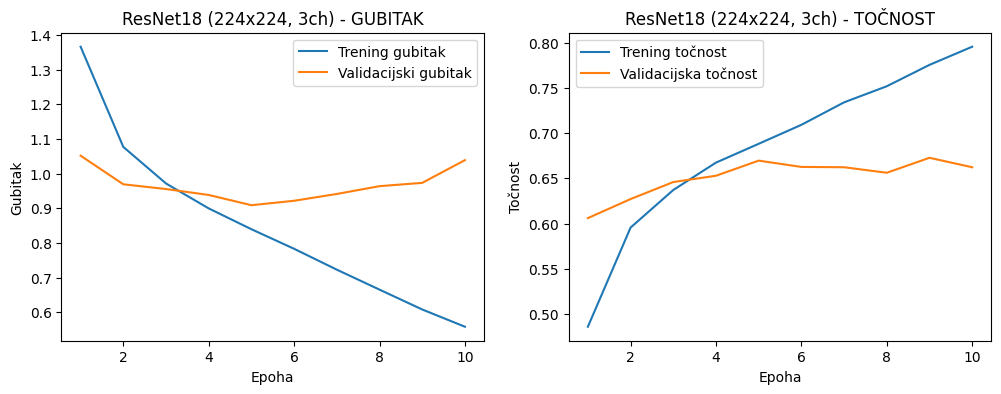


KONAČNA TOČNOST na testnom setu: 67.9298 %

=== Evaluacija: ResNet18 (224x224) ===
              precision    recall  f1-score   support

       angry       0.65      0.56      0.60       958
     disgust       0.61      0.68      0.65       111
        fear       0.56      0.46      0.50      1024
       happy       0.86      0.89      0.87      1774
     neutral       0.67      0.62      0.65      1233
         sad       0.51      0.62      0.56      1247
    surprise       0.77      0.81      0.79       831

    accuracy                           0.68      7178
   macro avg       0.66      0.66      0.66      7178
weighted avg       0.68      0.68      0.68      7178



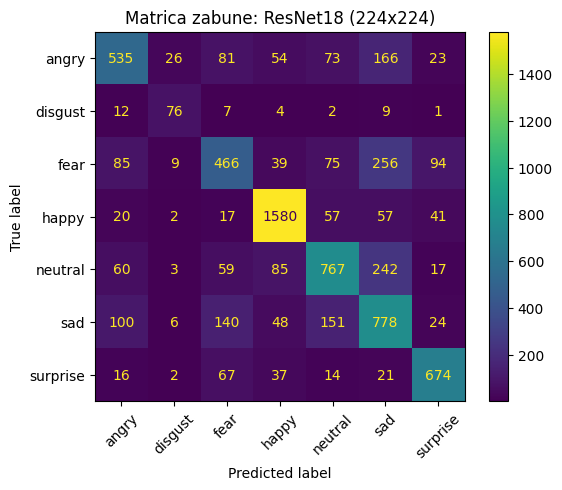

In [ ]:
print("\n\n--- Početak s ResNet18 (224x224, 3ch) ---")

model_resnet18 = resnet18(weights=ResNet18_Weights.DEFAULT)

# NE mijenjamo conv1 (ostaje 3-kanalni)
model_resnet18.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model_resnet18.fc.in_features, num_classes)
)

model_resnet18 = model_resnet18.to(device)

optimizer_resnet18 = optim.AdamW(model_resnet18.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

best_model_18, history_18 = train_and_validate(
    model_resnet18,
    train_data,
    val_data,
    criterion,
    optimizer_resnet18,
    num_epochs=10
)

plot_learning_curves(history_18, title="ResNet18 (224x224, 3ch)")
evaluate_on_test_set(best_model_18, test_data)
evaluate_model_with_cm(best_model_18, test_data, class_names, model_name="ResNet18 (224x224)")


# **RESNET50**



--- Početak s ResNet50 (224x224, 3ch) ---
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


----------
Epoha 1/10
Trening -> Gubitak: 1.4276 Točnost: 0.4448
Validacija -> Gubitak: 1.1158 Točnost: 0.5845
----------
Epoha 2/10
Trening -> Gubitak: 1.0719 Točnost: 0.5935
Validacija -> Gubitak: 0.9864 Točnost: 0.6313
----------
Epoha 3/10
Trening -> Gubitak: 0.9420 Točnost: 0.6461
Validacija -> Gubitak: 0.9893 Točnost: 0.6273
----------
Epoha 4/10
Trening -> Gubitak: 0.8579 Točnost: 0.6799
Validacija -> Gubitak: 0.9262 Točnost: 0.6573
----------
Epoha 5/10
Trening -> Gubitak: 0.7781 Točnost: 0.7081
Validacija -> Gubitak: 0.9393 Točnost: 0.6595
----------
Epoha 6/10
Trening -> Gubitak: 0.7029 Točnost: 0.7403
Validacija -> Gubitak: 0.9583 Točnost: 0.6658
----------
Epoha 7/10
Trening -> Gubitak: 0.6350 Točnost: 0.7673
Validacija -> Gubitak: 0.9763 Točnost: 0.6654
----------
Epoha 8/10
Trening -> Gubitak: 0.5678 Točnost: 0.7914
Validacija -> Gubitak: 1.0216 Točnost: 0.6677
----------
Epoha 9/10
Trening -> Gubitak: 0.5048 Točnost: 0.8178
Validacija -> Gubitak: 1.0591 Točnost: 0.6646
-

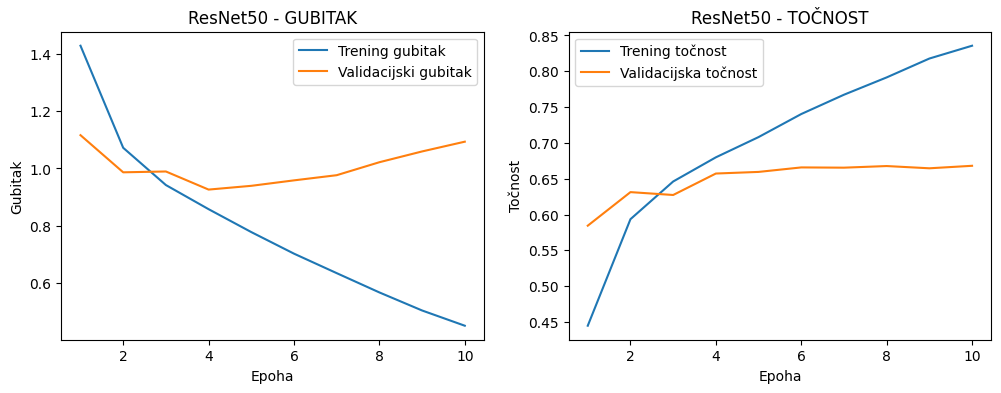


KONAČNA TOČNOST na testnom setu: 66.7595 %

=== Evaluacija: ResNet50 ===
              precision    recall  f1-score   support

       angry       0.61      0.55      0.57       958
     disgust       0.69      0.63      0.66       111
        fear       0.51      0.51      0.51      1024
       happy       0.87      0.86      0.87      1774
     neutral       0.62      0.65      0.63      1233
         sad       0.53      0.56      0.54      1247
    surprise       0.80      0.78      0.79       831

    accuracy                           0.67      7178
   macro avg       0.66      0.65      0.65      7178
weighted avg       0.67      0.67      0.67      7178



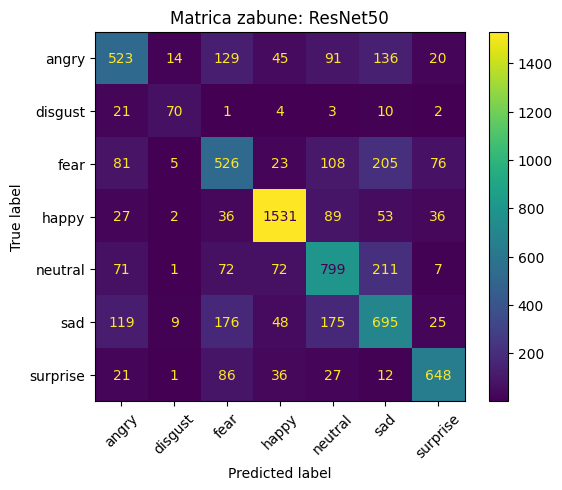

In [ ]:
print("\n\n--- Početak s ResNet50 (224x224, 3ch) ---")

model_resnet50 = resnet50(weights=ResNet50_Weights.DEFAULT)

num_classes = len(class_names)
model_resnet50.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model_resnet50.fc.in_features, num_classes)
)

model_resnet50 = model_resnet50.to(device)

optimizer_resnet50 = optim.AdamW(model_resnet50.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

best_model_50, history_50 = train_and_validate(
    model_resnet50,
    train_data,
    val_data,
    criterion,
    optimizer_resnet50,
    num_epochs=10
)

plot_learning_curves(history_50, title="ResNet50")
evaluate_on_test_set(best_model_50, test_data)
evaluate_model_with_cm(best_model_50, test_data, class_names, model_name="ResNet50")


# **EfficientNet**



--- Početak s EfficientNet-B0 (224x224, 3-kanal) ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]


----------
Epoha 1/10
Trening -> Gubitak: 1.3934 Točnost: 0.4651
Validacija -> Gubitak: 1.1034 Točnost: 0.5820
----------
Epoha 2/10
Trening -> Gubitak: 1.0785 Točnost: 0.5946
Validacija -> Gubitak: 0.9916 Točnost: 0.6268
----------
Epoha 3/10
Trening -> Gubitak: 0.9621 Točnost: 0.6390
Validacija -> Gubitak: 0.9534 Točnost: 0.6393
----------
Epoha 4/10
Trening -> Gubitak: 0.8853 Točnost: 0.6696
Validacija -> Gubitak: 0.9257 Točnost: 0.6522
----------
Epoha 5/10
Trening -> Gubitak: 0.8129 Točnost: 0.6957
Validacija -> Gubitak: 0.9195 Točnost: 0.6580
----------
Epoha 6/10
Trening -> Gubitak: 0.7540 Točnost: 0.7203
Validacija -> Gubitak: 0.9159 Točnost: 0.6668
----------
Epoha 7/10
Trening -> Gubitak: 0.6960 Točnost: 0.7425
Validacija -> Gubitak: 0.9265 Točnost: 0.6712
----------
Epoha 8/10
Trening -> Gubitak: 0.6310 Točnost: 0.7664
Validacija -> Gubitak: 0.9479 Točnost: 0.6773
----------
Epoha 9/10
Trening -> Gubitak: 0.5816 Točnost: 0.7868
Validacija -> Gubitak: 0.9654 Točnost: 0.6724
-

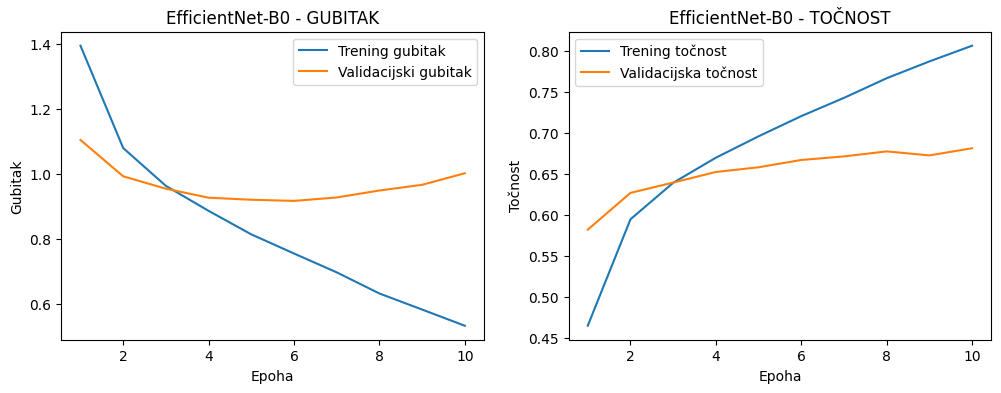


KONAČNA TOČNOST na testnom setu: 68.6542 %

=== Evaluacija: EfficientNet-B0 ===
              precision    recall  f1-score   support

       angry       0.63      0.57      0.60       958
     disgust       0.76      0.67      0.71       111
        fear       0.63      0.44      0.52      1024
       happy       0.86      0.89      0.88      1774
     neutral       0.63      0.64      0.64      1233
         sad       0.53      0.63      0.57      1247
    surprise       0.77      0.84      0.80       831

    accuracy                           0.69      7178
   macro avg       0.69      0.67      0.67      7178
weighted avg       0.69      0.69      0.68      7178



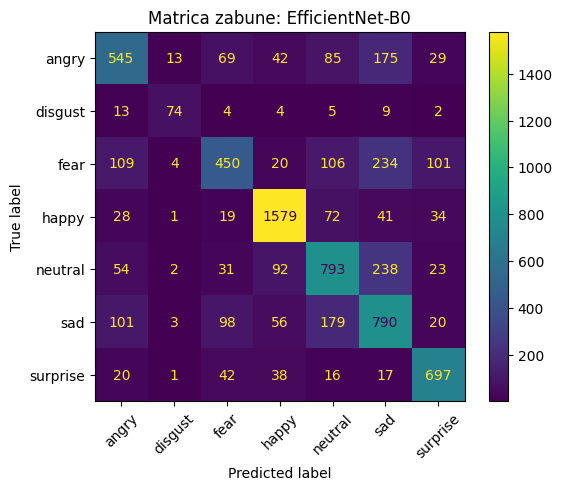

In [ ]:


from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

print("\n\n--- Početak s EfficientNet-B0 (224x224, 3-kanal) ---")

model_effb0 = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# NEMA promjene prvog conv sloja  (3 kanala)
model_effb0.classifier[1] = nn.Linear(model_effb0.classifier[1].in_features, num_classes)

model_effb0 = model_effb0.to(device)

optimizer_effb0 = optim.AdamW(model_effb0.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

best_model_effb0, history_effb0 = train_and_validate(
    model_effb0,
    train_data,
    val_data,
    criterion,
    optimizer_effb0,
    num_epochs=10
)

plot_learning_curves(history_effb0, title="EfficientNet-B0")

evaluate_on_test_set(best_model_effb0, test_data)
evaluate_model_with_cm(
    best_model_effb0,
    test_data,
    class_names,
    model_name="EfficientNet-B0"
)
